## Setup

Connects to the Brightway project and ecoinvent background database, and defines
the shared helper functions, method list, and units lookup used throughout this
notebook. This mirrors the setup in `01_LifeCycleInventory_master.ipynb` (Section 0)
and `02_LifeCycleImpactAssessment_burdens_EFv3_1.ipynb` (Sections 0–1), condensed
to what's needed here.

In [10]:
import bw2data as bd
import bw2io as bi
import bw2calc as bc
import pandas as pd

# ── Connect to project ────────────────────────────────────────────────────────
bd.projects.set_current("biopol_lca")
ei = bd.Database("ecoinvent-3.12-cutoff")
print(f"  ecoinvent: {len(ei)} datasets")

DB_NAME = "lca_database_3DPrintedBiopol"
db = bd.Database(DB_NAME)
print(f"  {DB_NAME}: {len(db)} activities")

  ecoinvent: 26533 datasets
  lca_database_3DPrintedBiopol: 16 activities


In [11]:
def find_activity(db, name):
    """Find a single foreground activity by exact name."""
    results = [a for a in db if a['name'] == name]
    if len(results) == 0:
        raise ValueError(f"Activity not found: '{name}'")
    if len(results) > 1:
        raise ValueError(f"Multiple activities found for: '{name}'")
    return results[0]


def find_ei(name, location, ref_product=None):
    """Look up an ecoinvent activity by exact name and location."""
    results = [
        a for a in ei
        if a['name'] == name
        and a['location'] == location
        and (ref_product is None or a.get('reference product') == ref_product)
    ]
    if len(results) == 0:
        raise ValueError(f"Ecoinvent dataset not found: '{name}' | {location}")
    if len(results) > 1:
        print(f"  Warning: multiple matches for '{name}' | {location} — using first")
    return results[0]

In [12]:
# ── All EF v3.1 methods ───────────────────────────────────────────────────────
EF_METHODS = [m for m in bd.methods if m[0] == 'EF v3.1']
print(f"Total EF v3.1 categories found: {len(EF_METHODS)}")

# ── EF v3.1 units lookup — keyed on method[1] ─────────────────────────────────
EF_UNITS = {
    'climate change':                               'kg CO2-eq',
    'climate change: biogenic':                     'kg CO2-eq',
    'climate change: fossil':                       'kg CO2-eq',
    'climate change: land use and land use change': 'kg CO2-eq',
    'land use':                                     'dimensionless (soil quality index)',
    'water use':                                    'm3 world-eq deprived',
    'energy resources: non-renewable':              'MJ',
    'material resources: metals/minerals':          'kg Sb-eq',
    'eutrophication: freshwater':                   'kg P-eq',
    'eutrophication: marine':                       'kg N-eq',
    'eutrophication: terrestrial':                  'mol N-eq',
    'acidification':                                'mol H+-eq',
    'ecotoxicity: freshwater':                      'CTUe',
    'human toxicity: carcinogenic':                 'CTUh',
    'human toxicity: non-carcinogenic':             'CTUh',
    'ionising radiation: human health':             'kBq U235-eq',
    'ozone depletion':                              'kg CFC-11-eq',
    'particulate matter formation':                 'disease incidences',
    'photochemical oxidant formation: human health':'kg NMVOC-eq',
}

Total EF v3.1 categories found: 25


## Recipe-level burden & benefit charts — segmented by material/process

Horizontal stacked bar charts for a fixed recipe (0.7 kg pea protein binder + 0.3 kg hemp dust filler
per 1 kg finished panel), reading unit burdens/benefits from `../results/for_html/`.

- Chart 1 — burdens: material segments (weighted by recipe fraction) + fixed process segments (added once per 1 kg product).
- Chart 2 — benefits: material segments only (weighted by recipe fraction) — no process benefits exist.

Both charts use the same 16 top-level EF v3.1 categories (climate change sub-splits and the
organics/inorganics ecotoxicity/human-toxicity sub-splits are excluded, matching the recipe explorer tool),
and the same category order, so the two charts are directly comparable.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_DIR = "../results/for_html"

df_mat_burdens  = pd.read_csv(f"{DATA_DIR}/perKgMaterial_burdens.csv")
df_mat_benefits = pd.read_csv(f"{DATA_DIR}/perKgMaterial_benefits.csv")
df_proc_burdens = pd.read_csv(f"{DATA_DIR}/perKgProcess_burdens.csv")

# ── Recipe under study ─────────────────────────────────────────────────────
RECIPE = {
    "Pea protein binder": 0.7,
    "Hemp dust filler": 0.3,
}

# ── 16 top-level EF v3.1 categories (excludes climate sub-splits and the
#    ecotoxicity/human-toxicity organics/inorganics sub-splits, consistent
#    with the recipe explorer tool) ─────────────────────────────────────────
CATEGORIES = [
    "climate change", "land use", "water use",
    "energy resources: non-renewable", "material resources: metals/minerals",
    "eutrophication: freshwater", "eutrophication: marine", "eutrophication: terrestrial",
    "acidification", "ecotoxicity: freshwater",
    "human toxicity: carcinogenic", "human toxicity: non-carcinogenic",
    "ionising radiation: human health", "ozone depletion",
    "particulate matter formation", "photochemical oxidant formation: human health",
]

SHORT_LABEL = {
    "climate change": "Climate change",
    "land use": "Land use",
    "water use": "Water use",
    "energy resources: non-renewable": "Non-renew. energy",
    "material resources: metals/minerals": "Metals/minerals",
    "eutrophication: freshwater": "Eutrophication (fresh.)",
    "eutrophication: marine": "Eutrophication (marine)",
    "eutrophication: terrestrial": "Eutrophication (terr.)",
    "acidification": "Acidification",
    "ecotoxicity: freshwater": "Ecotoxicity (freshwater)",
    "human toxicity: carcinogenic": "Human toxicity (carc.)",
    "human toxicity: non-carcinogenic": "Human toxicity (non-carc.)",
    "ionising radiation: human health": "Ionising radiation",
    "ozone depletion": "Ozone depletion",
    "particulate matter formation": "Particulate matter",
    "photochemical oxidant formation: human health": "Photochemical ox.",
}

In [27]:
def material_segment_scores(df, materials_fractions, categories):
    """Recipe-weighted normalised score per (segment=material, category)."""
    out = pd.DataFrame(index=categories, columns=materials_fractions.keys(), dtype=float)
    for mat, frac in materials_fractions.items():
        sub = df[df["material"] == mat].set_index("category")["normalised_score"]
        out[mat] = [sub.get(cat, 0.0) * frac for cat in categories]
    return out

def process_segment_scores(df, categories, process_order=None):
    """Fixed normalised score per (segment=process, category) — not recipe-weighted."""
    processes = process_order if process_order is not None else sorted(df["process"].unique())
    out = pd.DataFrame(index=categories, columns=processes, dtype=float)
    for proc in processes:
        sub = df[df["process"] == proc].set_index("category")["normalised_score"]
        out[proc] = [sub.get(cat, 0.0) for cat in categories]
    return out

PROCESS_ORDER = [
    "Mix preparation",
    "3D printing",
    # "Drying",
    "Kiln baking",
    "On-site panel repair",
    "EoL: incineration",
]

# Chart 1 — burdens: materials (recipe-weighted) + processes (fixed, in PROCESS_ORDER)
burden_materials = material_segment_scores(df_mat_burdens, RECIPE, CATEGORIES)
burden_processes = process_segment_scores(df_proc_burdens, CATEGORIES, process_order=PROCESS_ORDER)
burden_segments = pd.concat([burden_materials, burden_processes], axis=1)

# Chart 2 — benefits: materials only (recipe-weighted)
benefit_segments = material_segment_scores(df_mat_benefits, RECIPE, CATEGORIES)

print("Burden segments:", list(burden_segments.columns))
print("Benefit segments:", list(benefit_segments.columns))

Burden segments: ['Pea protein binder', 'Hemp dust filler', 'Mix preparation', '3D printing', 'Kiln baking', 'On-site panel repair', 'EoL: incineration']
Benefit segments: ['Pea protein binder', 'Hemp dust filler']


In [28]:
def stacked_hbar(ax, segments_df, colors, categories, short_labels):
    """
    Draws a horizontal stacked bar chart from a (category x segment) DataFrame,
    correctly stacking positive and negative segment values on their own side
    of zero (so a chart stays readable even if a segment's sign varies by
    category — e.g. a filler with a positive climate-change value elsewhere).
    """
    y_pos = range(len(categories))
    pos_offset = pd.Series(0.0, index=categories)
    neg_offset = pd.Series(0.0, index=categories)

    for seg in segments_df.columns:
        values = segments_df[seg].reindex(categories).fillna(0.0)
        left = values.where(values < 0, 0).radd(0)  # placeholder, replaced below
        lefts = []
        for cat, v in values.items():
            if v >= 0:
                lefts.append(pos_offset[cat])
                pos_offset[cat] += v
            else:
                neg_offset[cat] += v
                lefts.append(neg_offset[cat] - v)
        ax.barh(
            list(y_pos), values.values, left=lefts,
            color=colors.get(seg, "#999999"), edgecolor="white", linewidth=0.4,
            height=0.65, label=seg,
        )

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([short_labels.get(c, c) for c in categories])
    ax.invert_yaxis()  # first category at top
    ax.axvline(0, color="black", linewidth=0.8)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

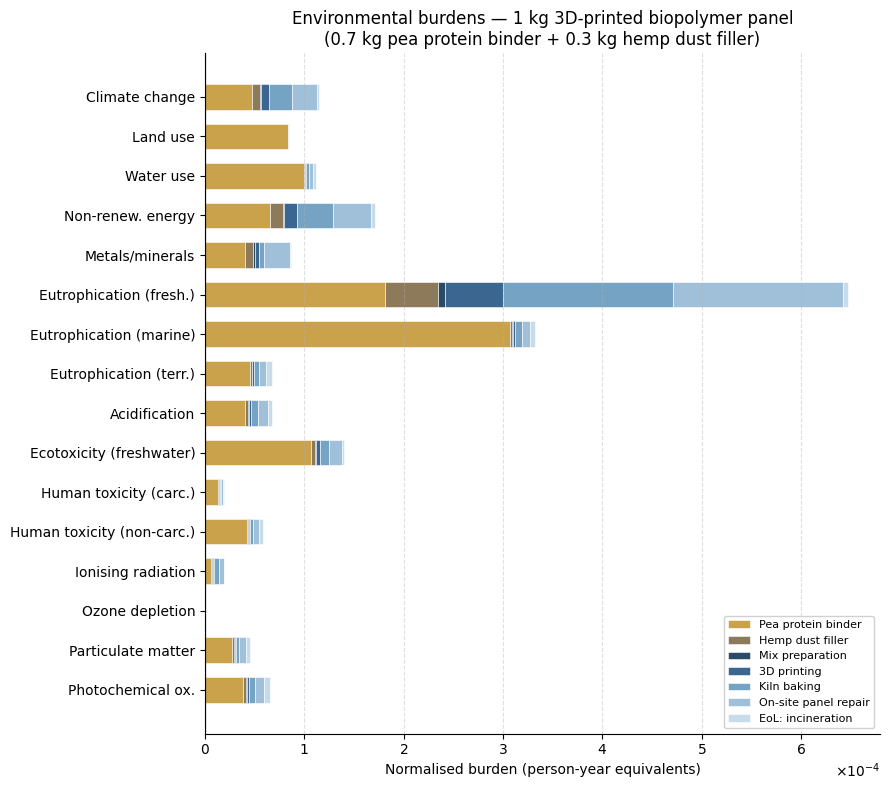

In [29]:
MATERIAL_COLORS = {
    "Pea protein binder": "#c9a24b",
    "Hemp dust filler": "#8c7a5a",
}
PROCESS_COLORS = {
    "Mix preparation": "#2b4a63",
    "3D printing": "#3a6690",
    # "Drying": "#4f84b0",
    "Kiln baking": "#74a3c4",
    "On-site panel repair": "#9fc0d8",
    "EoL: incineration": "#c6dceb",
}
BURDEN_COLORS = {**MATERIAL_COLORS, **PROCESS_COLORS}

fig, ax = plt.subplots(figsize=(9, 8))
stacked_hbar(ax, burden_segments, BURDEN_COLORS, CATEGORIES, SHORT_LABEL)
ax.set_xlabel("Normalised burden (person-year equivalents)")
ax.set_title("Environmental burdens — 1 kg 3D-printed biopolymer panel\n(0.7 kg pea protein binder + 0.3 kg hemp dust filler)")
ax.legend(loc="lower right", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig("recipe_burdens_by_segment.png", dpi=150, bbox_inches="tight")
plt.show()

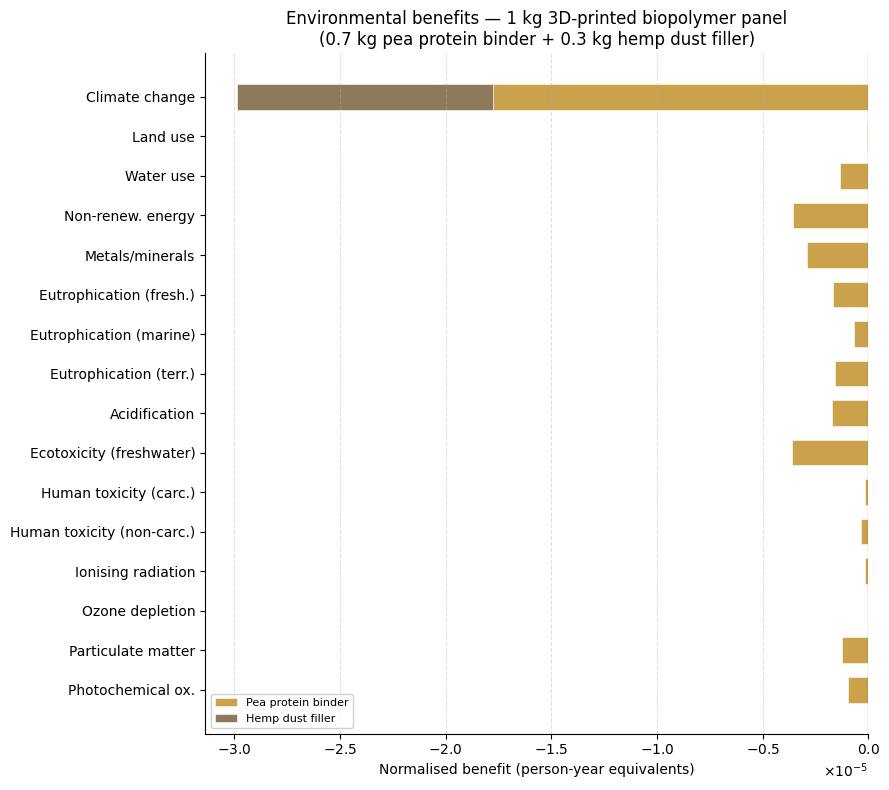

In [30]:
fig, ax = plt.subplots(figsize=(9, 8))
stacked_hbar(ax, benefit_segments, MATERIAL_COLORS, CATEGORIES, SHORT_LABEL)
ax.set_xlabel("Normalised benefit (person-year equivalents)")
ax.set_title("Environmental benefits — 1 kg 3D-printed biopolymer panel\n(0.7 kg pea protein binder + 0.3 kg hemp dust filler)")
ax.legend(loc="lower left", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig("recipe_benefits_by_segment.png", dpi=150, bbox_inches="tight")
plt.show()

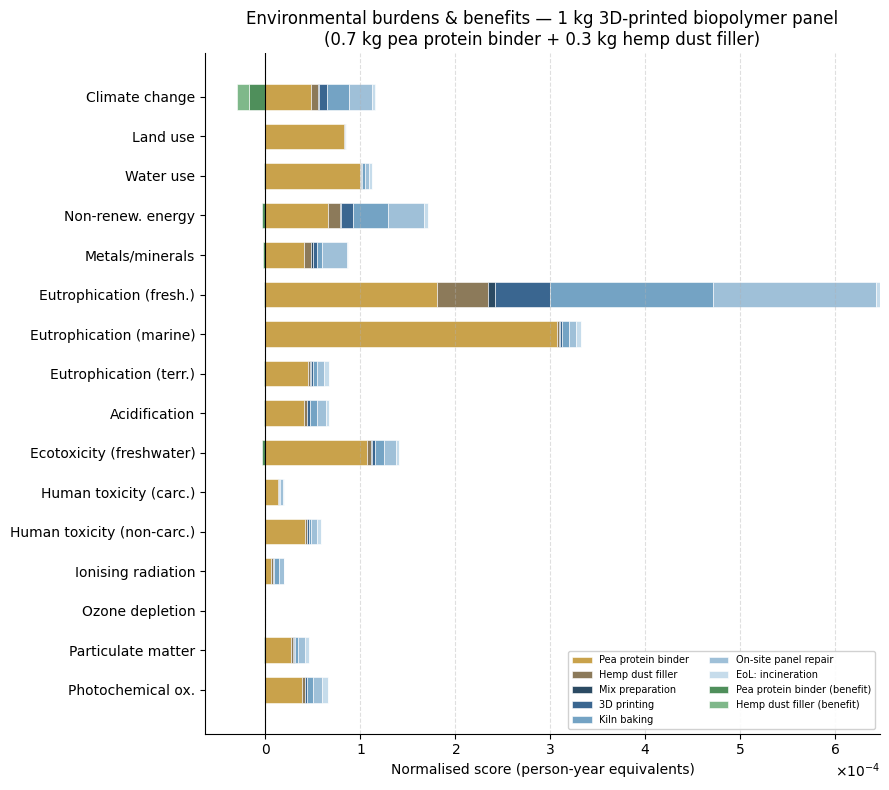

In [31]:
# Combine all segments (materials — burden and benefit — and processes) onto one axis.
# Benefit material segments get a distinct color from their burden counterparts so you
# can tell "Pea protein binder (burden)" apart from "Pea protein binder (benefit)".
BENEFIT_MATERIAL_COLORS = {
    "Pea protein binder (benefit)": "#4f8f5b",
    "Hemp dust filler (benefit)": "#7fb88a",
}

benefit_segments_renamed = benefit_segments.rename(
    columns={mat: f"{mat} (benefit)" for mat in benefit_segments.columns}
)

combined_segments = pd.concat([burden_segments, benefit_segments_renamed], axis=1)

COMBINED_COLORS = {**BURDEN_COLORS, **BENEFIT_MATERIAL_COLORS}

fig, ax = plt.subplots(figsize=(9, 8))
stacked_hbar(ax, combined_segments, COMBINED_COLORS, CATEGORIES, SHORT_LABEL)
ax.set_xlabel("Normalised score (person-year equivalents)")
ax.set_title("Environmental burdens & benefits — 1 kg 3D-printed biopolymer panel\n(0.7 kg pea protein binder + 0.3 kg hemp dust filler)")
ax.legend(loc="lower right", fontsize=7, framealpha=0.9, ncol=2)
plt.tight_layout()
plt.savefig("recipe_burdens_and_benefits_combined.png", dpi=150, bbox_inches="tight")
plt.show()

## Ingredients vs. digital fabrication processes — burden comparison

Horizontal bar charts comparing the environmental burden of each recipe component,
for four impact categories: climate change, land use, eutrophication (freshwater),
and eutrophication (marine).

Each chart has one row per component:
- **All production processes (1 kg panel)** — a single segmented bar, colored by
  Brightway activity (mix preparation → 3D printing → drying → kiln baking →
  on-site repair → EoL incineration), representing the full digital fabrication
  chain per 1 kg of finished panel.
- **Pea protein binder (0.7 kg)** — the burden of the binder fraction actually
  used in the recipe.
- **Filler (0.3 kg)**, one row per candidate filler — the burden each filler
  *would* contribute at its 0.3 kg recipe share, shown side by side so filler
  choice can be compared directly.

Values are raw (non-normalised) `score`s in each category's native unit, read from
`../results/for_html/perKgMaterial_burdens.csv` and `../results/for_html/perKgProcess_burdens.csv`.

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_DIR = "../results/for_html"

df_mat_burdens  = pd.read_csv(f"{DATA_DIR}/perKgMaterial_burdens.csv")
df_mat_benefits = pd.read_csv(f"{DATA_DIR}/perKgMaterial_benefits.csv")
df_proc_burdens = pd.read_csv(f"{DATA_DIR}/perKgProcess_burdens.csv")

# ── Recipe under study ─────────────────────────────────────────────────────
BINDER = "Pea protein binder"
BINDER_FRACTION = 0.7
FILLER_FRACTION = 0.3
FILLERS = [
    "Bark flour filler",
    "Cellulose filler",
    "Cotton filler",
    "Hemp dust filler",
    "Seagrass filler",
    "Wood flour filler",
]

PROCESS_ORDER = [
    "Mix preparation",
    "3D printing",
    # "Drying",
    "Kiln baking",
    "On-site panel repair",
    "EoL: incineration",
]

# ── Impact categories for this figure ──────────────────────────────────────
CATEGORIES = [
    "climate change",
    "land use",
    "eutrophication: freshwater",
    "eutrophication: marine",
]
SHORT_LABEL = {
    "climate change": "Climate change",
    "land use": "Land use",
    "eutrophication: freshwater": "Eutrophication (freshwater)",
    "eutrophication: marine": "Eutrophication (marine)",
}

# Categories for which ingredient rows should include a benefit segment
# alongside the burden segment (sign preserved as-is — credits are already
# negative in perKgMaterial_benefits.csv where applicable).
BENEFIT_CATEGORIES = {"climate change"}

# ── Colors ──────────────────────────────────────────────────────────────────
PROCESS_COLORS = {
    "Mix preparation": "#2b4a63",
    "3D printing": "#3a6690",
    # "Drying": "#4f84b0",
    "Kiln baking": "#74a3c4",
    "On-site panel repair": "#9fc0d8",
    "EoL: incineration": "#c6dceb",
}
BINDER_COLOR = "#c9a24b"
FILLER_COLORS = {
    "Bark flour filler": "#6a994e",
    "Cellulose filler": "#a7c957",
    "Cotton filler": "#f2cc8f",
    "Hemp dust filler": "#8c7a5a",
    "Seagrass filler": "#588157",
    "Wood flour filler": "#bc8a5f",
}
BENEFIT_COLOR = "#2a9d8f"
BENEFIT_HATCH = "///"
BENEFIT_SUFFIX = " (benefit)"

In [33]:
def process_segments_for_category(df, category, process_order):
    """Score per process activity for one category (not recipe-weighted — the
    full process chain runs once per 1 kg panel)."""
    sub = df[df["category"] == category].set_index("process")["score"]
    return {proc: sub.get(proc, 0.0) for proc in process_order}


def component_rows_for_category(df_mat_burdens, df_proc, category, df_mat_benefits=None):
    """
    Builds the ordered list of rows for one impact-category chart:
      1. "Production processes" — dict of {process: score} segments
      2. binder row — {binder: burden} (+ {binder (benefit): benefit} if
         `category` is in BENEFIT_CATEGORIES)
      3..n filler rows — same pattern as the binder row

    Returns: list of (row_label, kind, segments_dict). 'kind' is kept for
    compatibility but is always "segments" now — single-value rows are just
    a 1-entry dict.
    """
    burden_scores = df_mat_burdens[df_mat_burdens["category"] == category].set_index("material")["score"]
    benefit_scores = None
    if df_mat_benefits is not None and category in BENEFIT_CATEGORIES:
        benefit_scores = df_mat_benefits[df_mat_benefits["category"] == category].set_index("material")["score"]

    def material_row(label_name, frac):
        segs = {label_name: burden_scores.get(label_name, 0.0) * frac}
        if benefit_scores is not None:
            segs[f"{label_name}{BENEFIT_SUFFIX}"] = benefit_scores.get(label_name, 0.0) * frac
        return segs

    rows = []
    rows.append((
        "All production processes\n(1 kg panel)",
        "segments",
        process_segments_for_category(df_proc, category, PROCESS_ORDER),
    ))
    rows.append((
        f"{BINDER} ({BINDER_FRACTION} kg)",
        "segments",
        material_row(BINDER, BINDER_FRACTION),
    ))
    for filler in FILLERS:
        rows.append((
            f"{filler} ({FILLER_FRACTION} kg)",
            "segments",
            material_row(filler, FILLER_FRACTION),
        ))
    return rows


def category_unit(df, category):
    units = df[df["category"] == category]["unit"].unique()
    return units[0] if len(units) else ""

In [34]:
def segment_style(name):
    """Returns (color, hatch) for a segment name."""
    if name.endswith(BENEFIT_SUFFIX):
        return BENEFIT_COLOR, BENEFIT_HATCH
    if name == BINDER:
        return BINDER_COLOR, None
    if name in PROCESS_COLORS:
        return PROCESS_COLORS[name], None
    if name in FILLER_COLORS:
        return FILLER_COLORS[name], None
    return "#999999", None


def plot_component_bars(ax, rows, category, unit):
    """Draws one horizontal bar chart. Each row's segments are stacked
    sign-aware — positive segments extend right of zero, negative segments
    extend left of zero — so a burden+benefit row reads correctly regardless
    of the benefit's sign."""
    y_labels = [label for label, kind, segments in rows]
    y_pos = list(range(len(rows)))

    for y, (label, kind, segments) in zip(y_pos, rows):
        pos_offset = 0.0
        neg_offset = 0.0
        for seg_name, seg_value in segments.items():
            color, hatch = segment_style(seg_name)
            if seg_value >= 0:
                left = pos_offset
                pos_offset += seg_value
            else:
                neg_offset += seg_value
                left = neg_offset - seg_value
            ax.barh(
                y, seg_value, left=left,
                color=color, edgecolor="white", linewidth=0.4, height=0.65,
                label=seg_name, hatch=hatch,
            )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels, fontsize=8)
    ax.invert_yaxis()  # processes row at top
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel(unit, fontsize=8)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    title = SHORT_LABEL.get(category, category)
    if category in BENEFIT_CATEGORIES:
        title += "\n(burdens + benefits)"
    ax.set_title(title, fontsize=10, fontweight="bold")

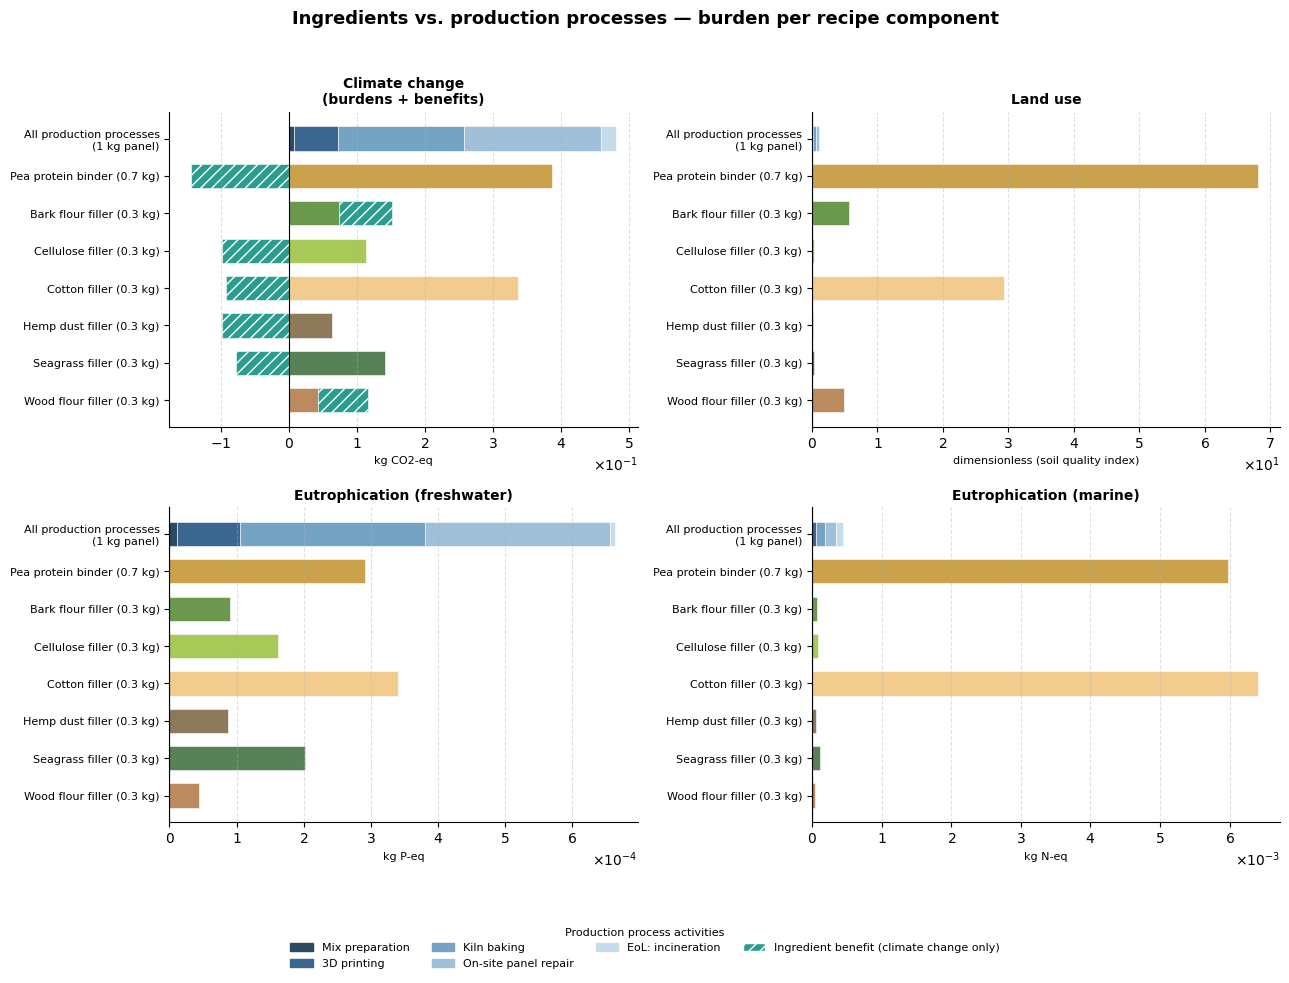

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))

for ax, category in zip(axes.flat, CATEGORIES):
    rows = component_rows_for_category(df_mat_burdens, df_proc_burdens, category, df_mat_benefits)
    unit = category_unit(df_mat_burdens, category)
    plot_component_bars(ax, rows, category, unit)

fig.suptitle(
    "Ingredients vs. production processes — burden per recipe component",
    fontsize=13, fontweight="bold",
)

process_handles = [plt.Rectangle((0, 0), 1, 1, color=PROCESS_COLORS[p]) for p in PROCESS_ORDER]
benefit_handle = plt.Rectangle((0, 0), 1, 1, facecolor=BENEFIT_COLOR, hatch=BENEFIT_HATCH, edgecolor="white")
legend_handles = process_handles + [benefit_handle]
legend_labels = PROCESS_ORDER + ["Ingredient benefit (climate change only)"]

fig.legend(
    legend_handles, legend_labels,
    title="Production process activities",
    loc="lower center", ncol=4, fontsize=8, title_fontsize=8,
    bbox_to_anchor=(0.5, -0.04), frameon=False,
)

plt.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.savefig("ingredients_vs_processes_burdens.png", dpi=150, bbox_inches="tight")
plt.show()

## Processes, ingredients, and transport distance — burden comparison

Extends the previous component-comparison chart with a transport dimension.
Four impact categories (climate change, land use, eutrophication freshwater,
eutrophication marine), one chart each. Each chart has:

- **All production processes (1 kg panel)** — segmented by activity, same as before.
- **Ingredients (0.7 kg binder + 0.3 kg bark flour filler)** — a single stacked
  bar, segmented by ingredient, representing this specific recipe.
- **Transport, 50 / 100 / 500 km (1 kg material)** — three bars showing how the
  transport burden alone scales with distance, using the per-kg·km unit impact
  computed in Part A.

Reads `perKgMaterial_burdens.csv`, `perKgProcess_burdens.csv`, and
`perKgKm_transport_burdens.csv` from `../results/for_html/`.

### Unit impact of transport — per t·km and per kg·km

Retrieves the unit LCIA score of the background transport dataset used throughout
this study (`market for transport, freight, lorry, unspecified | RER`, Section 3
convention), for the four focal categories. The functional unit is 1 t·km; this is
converted to 1 kg·km (× 0.001) so it can be scaled directly by distance and by the
mass of material being moved downstream.

In [36]:
# ── Unit impact of transport (per t·km and per kg·km) ─────────────────────────
ei_transport = find_ei(
    "market for transport, freight, lorry, unspecified", "RER",
    ref_product="transport, freight, lorry, diesel, unspecified"
)

TRANSPORT_CATEGORIES = [
    "climate change",
    "land use",
    "eutrophication: freshwater",
    "eutrophication: marine",
]
TRANSPORT_METHODS = EF_METHODS # [m for m in EF_METHODS if m[1] in TRANSPORT_CATEGORIES]

transport_unit_rows = []
for method in TRANSPORT_METHODS:
    lca = bc.LCA({ei_transport: 1}, method)   # functional unit: 1 t·km
    lca.lci()
    lca.lcia()
    transport_unit_rows.append({
        "category": method[1],
        "score_per_tkm": lca.score,
        "score_per_kg_km": lca.score * 0.001,   # 1 kg·km = 0.001 t·km
        "unit": EF_UNITS.get(method[1], "—"),
    })

df_transport_unit = (
    pd.DataFrame(transport_unit_rows)
    .sort_values("category")
    .reset_index(drop=True)
)

df_transport_unit.to_csv("../results/for_html/perKgKm_transport_burdens.csv", index=False)
df_transport_unit

,category,score_per_tkm,score_per_kg_km,unit
0,acidification,6.811773e-04,6.811773e-07,mol H+-eq
1,climate change,1.506980e-01,1.506980e-04,kg CO2-eq
2,climate change: biogenic,2.973964e-05,2.973964e-08,kg CO2-eq
3,climate change: fossil,1.506173e-01,1.506173e-04,kg CO2-eq
4,climate change: land use and land use change,5.092841e-05,5.092841e-08,kg CO2-eq
5,ecotoxicity: freshwater,3.191096e-01,3.191096e-04,CTUe
6,"ecotoxicity: freshwater, inorganics",3.038035e-01,3.038035e-04,—
7,"ecotoxicity: freshwater, organics",1.530617e-02,1.530617e-05,—
8,energy resources: non-renewable,2.161959e+00,2.161959e-03,MJ
9,eutrophication: freshwater,1.082206e-05,1.082206e-08,kg P-eq


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_DIR = "../results/for_html"

df_mat_burdens    = pd.read_csv(f"{DATA_DIR}/perKgMaterial_burdens.csv")
df_proc_burdens   = pd.read_csv(f"{DATA_DIR}/perKgProcess_burdens.csv")
df_transport_unit = pd.read_csv(f"{DATA_DIR}/perKgKm_transport_burdens.csv")

# ── Recipe under study ─────────────────────────────────────────────────────
BINDER = "Pea protein binder"
BINDER_FRACTION = 0.7
FILLER = "Bark flour filler"
FILLER_FRACTION = 0.3

PROCESS_ORDER = [
    "Mix preparation",
    "3D printing",
    # "Drying",
    "Kiln baking",
    "On-site panel repair",
    "EoL: incineration",
]

TRANSPORT_DISTANCES_KM = [50, 100, 500]

# ── Impact categories for this figure ──────────────────────────────────────
CATEGORIES = [
    "climate change",
    "land use",
    "eutrophication: freshwater",
    "eutrophication: marine",
]
SHORT_LABEL = {
    "climate change": "Climate change",
    "land use": "Land use",
    "eutrophication: freshwater": "Eutrophication (freshwater)",
    "eutrophication: marine": "Eutrophication (marine)",
}

# ── Colors ──────────────────────────────────────────────────────────────────
PROCESS_COLORS = {
    "Mix preparation": "#2b4a63",
    "3D printing": "#3a6690",
    "Drying": "#4f84b0",
    "Kiln baking": "#74a3c4",
    "On-site panel repair": "#9fc0d8",
    "EoL: incineration": "#c6dceb",
}
INGREDIENT_COLORS = {
    BINDER: "#c9a24b",
    FILLER: "#6a994e",
}
SEGMENT_COLORS = {**PROCESS_COLORS, **INGREDIENT_COLORS}
TRANSPORT_COLORS = {
    50: "#f4a261",
    100: "#e76f51",
    500: "#9c3b1f",
}

In [38]:
def process_segments_for_category(df, category, process_order):
    """Score per process activity for one category (full chain runs once per 1 kg panel)."""
    sub = df[df["category"] == category].set_index("process")["score"]
    return {proc: sub.get(proc, 0.0) for proc in process_order}


def ingredient_segments_for_category(df, category):
    """Recipe-weighted score per ingredient (0.7 kg binder + 0.3 kg bark flour filler)."""
    sub = df[df["category"] == category].set_index("material")["score"]
    return {
        BINDER: sub.get(BINDER, 0.0) * BINDER_FRACTION,
        FILLER: sub.get(FILLER, 0.0) * FILLER_FRACTION,
    }


def transport_score_for_category(df, category, distance_km):
    """Transport burden of moving 1 kg of material the given distance."""
    row = df[df["category"] == category]
    if row.empty:
        return 0.0
    return row["score_per_kg_km"].iloc[0] * distance_km


def component_rows_for_category(df_mat, df_proc, df_transport, category):
    process_segments = process_segments_for_category(df_proc, category, PROCESS_ORDER)
    ingredient_segments = ingredient_segments_for_category(df_mat, category)
    # Baseline = production processes + ingredients, i.e. everything each
    # transport bar is being expressed as a percentage of.
    baseline_total = sum(process_segments.values()) + sum(ingredient_segments.values())

    rows = []
    rows.append({
        "label": "All production processes\n(1 kg panel)",
        "kind": "segments",
        "value": process_segments,
    })
    rows.append({
        "label": f"Ingredients\n({BINDER_FRACTION} kg binder + {FILLER_FRACTION} kg filler)",
        "kind": "segments",
        "value": ingredient_segments,
    })
    for km in TRANSPORT_DISTANCES_KM:
        value = transport_score_for_category(df_transport, category, km)
        pct = (value / baseline_total * 100) if baseline_total else float("nan")
        rows.append({
            "label": f"Transport, {km} km\n(1 kg material)",
            "kind": "single",
            "value": value,
            "color": TRANSPORT_COLORS[km],
            "pct_label": f"{pct:.1f}% of processes + ingredients",
        })
    return rows


def category_unit(df, category):
    units = df[df["category"] == category]["unit"].unique()
    return units[0] if len(units) else ""

In [39]:
def plot_component_bars(ax, rows, category, unit):
    """Draws one horizontal bar chart: processes and ingredients rows are
    segmented; transport rows are single solid-color bars, labeled with their
    share of the processes+ingredients baseline."""
    y_labels = [r["label"] for r in rows]
    y_pos = list(range(len(rows)))
    text_annotations = []  # (y, value, label) — added after bars, once xlim is known

    for y, row in zip(y_pos, rows):
        if row["kind"] == "segments":
            left = 0.0
            for seg_name, seg_value in row["value"].items():
                ax.barh(
                    y, seg_value, left=left,
                    color=SEGMENT_COLORS.get(seg_name, "#999999"),
                    edgecolor="white", linewidth=0.4, height=0.65,
                    label=seg_name,
                )
                left += seg_value
        else:
            ax.barh(
                y, row["value"], color=row["color"],
                edgecolor="white", linewidth=0.4, height=0.65,
            )
            if "pct_label" in row:
                text_annotations.append((y, row["value"], row["pct_label"]))

    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels, fontsize=8)
    ax.invert_yaxis()
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel(unit, fontsize=8)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(SHORT_LABEL.get(category, category), fontsize=10, fontweight="bold")

    # ── Percentage labels for transport bars, placed to the right of each bar ──
    xlim = ax.get_xlim()
    offset = 0.015 * (xlim[1] - xlim[0])
    for y, value, label in text_annotations:
        if value >= 0:
            ax.text(value + offset, y, label, va="center", ha="left", fontsize=7, color="#333333")
        else:
            ax.text(value - offset, y, label, va="center", ha="right", fontsize=7, color="#333333")
    # widen the axis so labels don't get clipped at the figure edge
    ax.set_xlim(xlim[0], xlim[1] + 0.28 * (xlim[1] - xlim[0]))

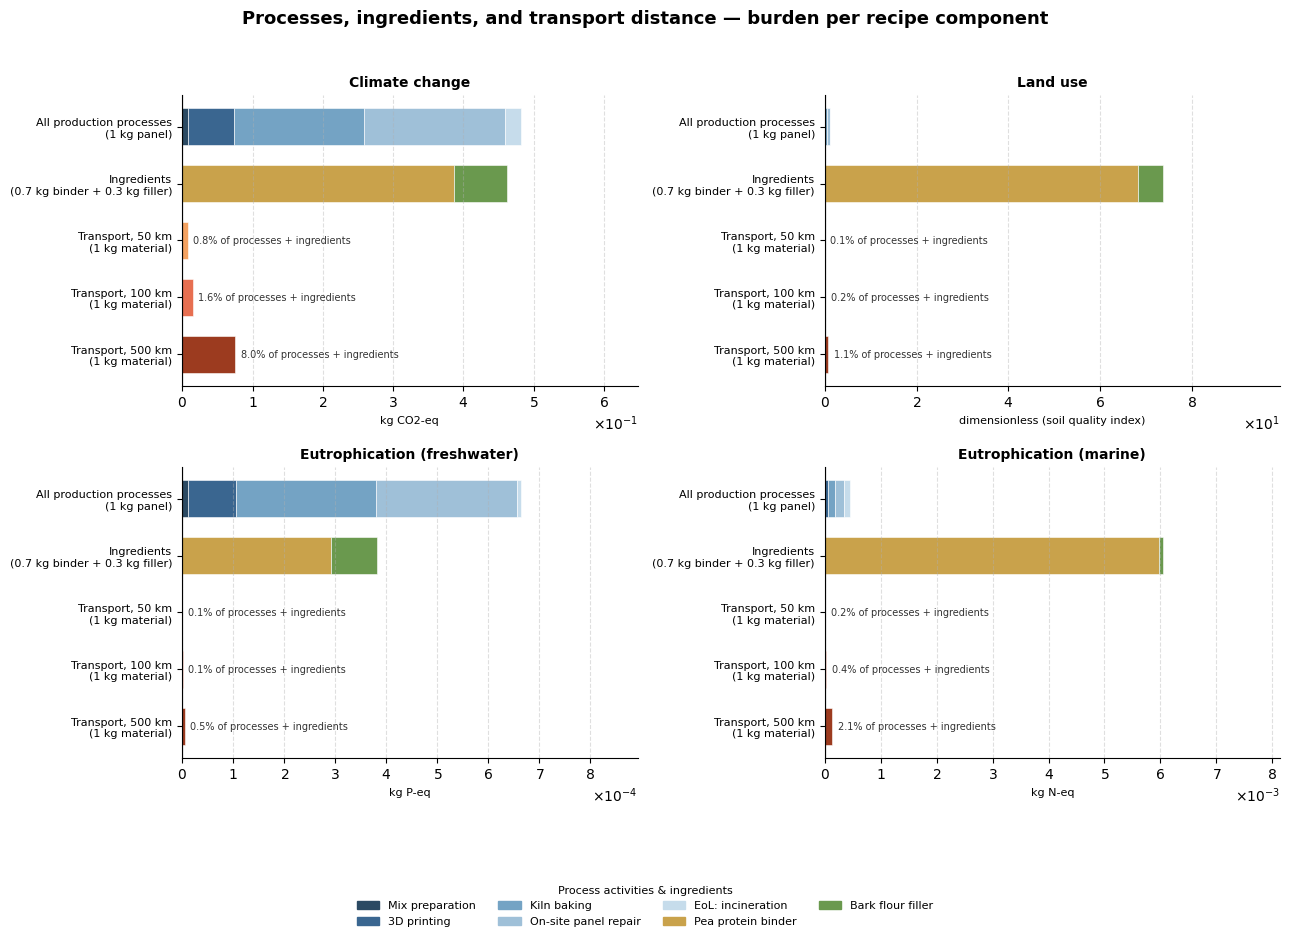

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, category in zip(axes.flat, CATEGORIES):
    rows = component_rows_for_category(df_mat_burdens, df_proc_burdens, df_transport_unit, category)
    unit = category_unit(df_mat_burdens, category)
    plot_component_bars(ax, rows, category, unit)

fig.suptitle(
    "Processes, ingredients, and transport distance — burden per recipe component",
    fontsize=13, fontweight="bold",
)

segment_labels = PROCESS_ORDER + [BINDER, FILLER]
segment_handles = [plt.Rectangle((0, 0), 1, 1, color=SEGMENT_COLORS[s]) for s in segment_labels]
fig.legend(
    segment_handles, segment_labels,
    title="Process activities & ingredients",
    loc="lower center", ncol=4, fontsize=8, title_fontsize=8,
    bbox_to_anchor=(0.5, -0.05), frameon=False,
)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.savefig("processes_ingredients_transport_burdens.png", dpi=150, bbox_inches="tight")
plt.show()

## Lifetime & repair sensitivity — burden, benefit, and net heatmaps

Explores how the climate change impact of 1 kg panel (0.7 kg pea protein binder +
0.3 kg bark flour filler) depends on two scenario levers:

- **Expected product lifetime** (25 / 50 / 100 yr) — the target total service life.
- **Lifetime extension per repair event** (5 / 10 / 25 yr) — how much service life
  each on-site repair buys back.

**Burden side.** Reuses the existing unit burdens (`perKgMaterial_burdens.csv`,
`perKgProcess_burdens.csv`). Production runs once regardless of scenario; on-site
repair is linear in the number of events, so the number of repairs needed to reach
the target lifetime is:

$$
N_{\text{repairs}} = \left\lceil \frac{\text{target lifetime} - \text{RSL}_{\text{baseline}}}{\text{extension per repair}} \right\rceil, \quad \text{floored at } 0
$$

using the fixed baseline reference service life (`RSL_BASELINE_YEARS = 25`,
`01_LifeCycleInventory_master.ipynb`, Section 12.1 — update here if that
parameter changes upstream).

**Benefit side.** The GWP_bio sequestration credit (Section 2 above) is
recomputed with the **storage period set to the target lifetime** rather than
the notebook's default 25 yr — the biogenic carbon stays locked in the panel
for as long as the panel itself lasts, regardless of how many repairs it took
to get there. Consequently the benefit heatmap varies **only by row**, not by
column — that's expected, not a bug, given this model.

**What's included vs. excluded.** This isolates the sequestration mechanism
specifically, per your request. The delayed-emissions credit (Section 3,
seagrass/cellulose only, not part of this recipe) and the nitrogen-fixation
avoided burden (Section 4, a small, lifetime-independent constant) are **not**
included here — adding Section 4's fixed offset back in would shift the benefit
and net heatmaps by a constant without changing their shape. Flag if you'd
like that added back in for full consistency with `perKgMaterial_benefits.csv`.

**Scope note.** Each cell is the *total* lifecycle climate change impact for
that scenario (production + N repairs, using the target lifetime as the
sequestration storage period) — not annualised per year of service. A panel
with a longer lifetime does more repairs and stores carbon longer, but this
chart doesn't divide by service life to compare them per-year; let me know if
you'd like an annualised version alongside this one.

In [69]:
import math
import numpy as np

DATA_DIR = "../results/for_html"
df_mat_burdens  = pd.read_csv(f"{DATA_DIR}/perKgMaterial_burdens.csv")
df_proc_burdens = pd.read_csv(f"{DATA_DIR}/perKgProcess_burdens.csv")

# ── Scenario grid ────────────────────────────────────────────────────────────
RECIPE = {"Pea protein binder": 0.7, "Bark flour filler": 0.3}
LIFETIME_YEARS = [25, 50, 100]
REPAIR_EXTENSION_YEARS = [5, 10, 25]
RSL_BASELINE_YEARS = 50  # fixed baseline reference service life without repair
                          # (01_LifeCycleInventory_master.ipynb, Section 12.1)

PROCESS_ORDER_NO_REPAIR = ["Mix preparation", "3D printing", "Drying", "Kiln baking", "EoL: incineration"]
REPAIR_PROCESS = "On-site panel repair"
IMPACT_CATEGORY = "climate change"


def n_repairs_needed(target_lifetime_yr, extension_per_repair_yr, baseline_yr=RSL_BASELINE_YEARS):
    """Number of repair events needed to reach at least the target lifetime."""
    if target_lifetime_yr <= baseline_yr:
        return 0
    return math.ceil((target_lifetime_yr - baseline_yr) / extension_per_repair_yr)


def get_score(df, key_col, key, category=IMPACT_CATEGORY):
    sub = df[(df[key_col] == key) & (df["category"] == category)]
    return sub["score"].iloc[0] if not sub.empty else 0.0


# ── Fixed burden components (recipe production + baseline processes) ─────────
ingredient_burden_total = sum(
    get_score(df_mat_burdens, "material", mat) * frac
    for mat, frac in RECIPE.items()
)
process_baseline_total = sum(
    get_score(df_proc_burdens, "process", proc) for proc in PROCESS_ORDER_NO_REPAIR
)
repair_unit_burden = get_score(df_proc_burdens, "process", REPAIR_PROCESS)

print(f"Ingredient burden total:  {ingredient_burden_total:.4f} kg CO2-eq")
print(f"Process baseline total:   {process_baseline_total:.4f} kg CO2-eq")
print(f"Repair unit burden:       {repair_unit_burden:.4f} kg CO2-eq/event")


def total_burden(target_lifetime_yr, extension_per_repair_yr):
    n = n_repairs_needed(target_lifetime_yr, extension_per_repair_yr)
    return ingredient_burden_total + process_baseline_total + n * repair_unit_burden

Ingredient burden total:  0.4614 kg CO2-eq
Process baseline total:   0.2807 kg CO2-eq
Repair unit burden:       0.2010 kg CO2-eq/event


In [70]:
# ── Derive kg peas per kg pea protein binder from the LCI chain ───────────────
def get_exchange_amount(node, producer_name_contains: str) -> float:
    """Return the amount of a technosphere exchange by (partial) producer name."""
    matches = [e for e in node.technosphere() if producer_name_contains in e.input['name']]
    if not matches:
        raise ValueError(f"No exchange found containing '{producer_name_contains}'")
    return matches[0]['amount']

node_isolate = bd.get_node(name="AEIEP pea protein isolate production", database=DB_NAME)
node_binder  = bd.get_node(name="pea protein binder production", database=DB_NAME)

kg_peas_per_kg_isolate    = get_exchange_amount(node_isolate, "protein pea")
kg_isolate_per_kg_binder  = get_exchange_amount(node_binder, "AEIEP pea protein isolate production")
kg_peas_per_kg_binder     = kg_peas_per_kg_isolate * kg_isolate_per_kg_binder

CARBON_FRACTION_PEA = 0.45  # pure whole dried pea, IPCC Tier 1 / Lal (2004)
carbon_fraction_binder = CARBON_FRACTION_PEA * kg_peas_per_kg_binder

print(f"kg peas / kg binder:              {kg_peas_per_kg_binder:.4f}")
print(f"Derived binder carbon fraction:   {carbon_fraction_binder:.4f}")

INGREDIENT_PARAMS = {
    "Pea protein binder": {"rotation_yr": 1,  "carbon_fraction": carbon_fraction_binder},
    "Hemp dust filler":   {"rotation_yr": 1,  "carbon_fraction": 0.47},
    "Bark flour filler":  {"rotation_yr": 80, "carbon_fraction": 0.50},
    "Wood flour filler":  {"rotation_yr": 80, "carbon_fraction": 0.48},
    "Cotton filler":      {"rotation_yr": 1,  "carbon_fraction": 0.44},
    # Seagrass: not sequestration-eligible. It's a wild growing plant, so we can't take credit for its carbon uptake. 
    # Cellulose: this is an industrial waste product, so it doesn't make sense to take credit for the carbon uptake of the tree it came from many life cycles ago. 
}

MOLAR_RATIO = 44 / 12     # kg C → kg CO2

# ── GWP_bio lookup table — Guest et al. (2012), Table 1, 100-yr TH ────────────
ROTATION_PERIODS = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
STORAGE_PERIODS  = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

GWPBIO_TABLE = {
     1:   [ 0.00, -0.07, -0.15, -0.23, -0.32, -0.40, -0.50, -0.60, -0.71, -0.84, -0.99],
    10:   [ 0.04, -0.04, -0.12, -0.20, -0.28, -0.37, -0.46, -0.57, -0.68, -0.80, -0.96],
    20:   [ 0.08,  0.00, -0.08, -0.16, -0.24, -0.33, -0.42, -0.53, -0.64, -0.76, -0.92],
    30:   [ 0.12,  0.04, -0.04, -0.12, -0.20, -0.29, -0.38, -0.48, -0.60, -0.72, -0.88],
    40:   [ 0.16,  0.09,  0.01, -0.08, -0.16, -0.25, -0.34, -0.44, -0.55, -0.68, -0.84],
    50:   [ 0.20,  0.13,  0.05, -0.03, -0.12, -0.21, -0.30, -0.40, -0.51, -0.64, -0.80],
    60:   [ 0.25,  0.17,  0.09,  0.01, -0.07, -0.16, -0.26, -0.36, -0.47, -0.59, -0.75],
    70:   [ 0.29,  0.22,  0.14,  0.06, -0.03, -0.12, -0.21, -0.31, -0.42, -0.55, -0.71],
    80:   [ 0.34,  0.26,  0.18,  0.10,  0.02, -0.07, -0.17, -0.27, -0.38, -0.50, -0.66],
    90:   [ 0.38,  0.31,  0.23,  0.15,  0.06, -0.03, -0.12, -0.22, -0.33, -0.46, -0.62],
   100:   [ 0.44,  0.37,  0.29,  0.21,  0.12,  0.032,-0.06, -0.16, -0.27, -0.40, -0.56],
}

def lookup_gwpbio(rotation_yr: int, storage_yr: float) -> float:
    """GWP_bio factor, linearly interpolated between 10-yr storage columns."""
    row = GWPBIO_TABLE[rotation_yr]
    if storage_yr % 10 == 0:
        return row[STORAGE_PERIODS.index(int(storage_yr))]
    lo = int(storage_yr // 10) * 10
    lo_idx, hi_idx = STORAGE_PERIODS.index(lo), STORAGE_PERIODS.index(lo + 10)
    t = (storage_yr - lo) / 10
    return row[lo_idx] + t * (row[hi_idx] - row[lo_idx])

kg peas / kg binder:              0.5893
Derived binder carbon fraction:   0.2652


In [71]:
def sequestration_credit(material_label, storage_yr):
    """GWP_bio sequestration credit per kg of material, with storage period
    set to `storage_yr` instead of the notebook's default PRODUCT_LIFETIME_YR."""
    p = INGREDIENT_PARAMS[material_label]
    gwp = lookup_gwpbio(p["rotation_yr"], storage_yr)
    return p["carbon_fraction"] * MOLAR_RATIO * gwp


def total_benefit(target_lifetime_yr):
    """Recipe-weighted sequestration credit, storage period = target lifetime.
    Deliberately independent of repair extension — see markdown note above."""
    return sum(
        sequestration_credit(mat, target_lifetime_yr) * frac
        for mat, frac in RECIPE.items()
    )


# ── Assemble the three grids ──────────────────────────────────────────────────
burden_grid = np.array([
    [total_burden(L, E) for E in REPAIR_EXTENSION_YEARS] for L in LIFETIME_YEARS
])
benefit_grid = np.array([
    [total_benefit(L) for E in REPAIR_EXTENSION_YEARS] for L in LIFETIME_YEARS
])
net_grid = burden_grid + benefit_grid

print("Burden grid (kg CO2-eq):\n", burden_grid, "\n")
print("Benefit grid (kg CO2-eq):\n", benefit_grid, "\n")
print("Net grid (kg CO2-eq):\n", net_grid)

Burden grid (kg CO2-eq):
 [[0.74214396 0.74214396 0.74214396]
 [0.74214396 0.74214396 0.74214396]
 [2.75226038 1.74720217 1.14416724]] 

Benefit grid (kg CO2-eq):
 [[-0.05231386 -0.05231386 -0.05231386]
 [-0.3107397  -0.3107397  -0.3107397 ]
 [-1.03679326 -1.03679326 -1.03679326]] 

Net grid (kg CO2-eq):
 [[0.6898301  0.6898301  0.6898301 ]
 [0.43140426 0.43140426 0.43140426]
 [1.71546712 0.71040891 0.10737399]]


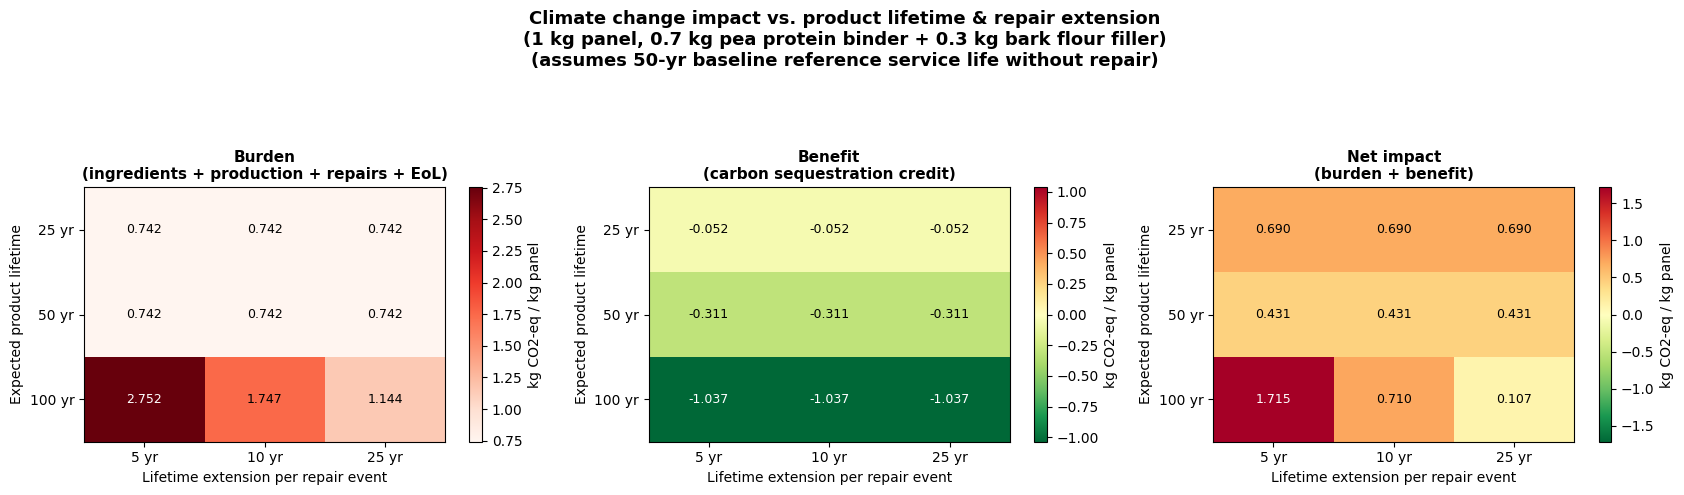

In [72]:
def plot_heatmap(ax, grid, title, cmap, center_zero=False, fmt="{:.3f}"):
    if center_zero:
        vmax = np.max(np.abs(grid))
        vmin = -vmax
    else:
        vmin, vmax = grid.min(), grid.max()
    im = ax.imshow(grid, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(REPAIR_EXTENSION_YEARS)))
    ax.set_xticklabels([f"{e} yr" for e in REPAIR_EXTENSION_YEARS])
    ax.set_yticks(range(len(LIFETIME_YEARS)))
    ax.set_yticklabels([f"{l} yr" for l in LIFETIME_YEARS])
    ax.set_xlabel("Lifetime extension per repair event")
    ax.set_ylabel("Expected product lifetime")
    ax.set_title(title, fontsize=11, fontweight="bold")

    # Text color from actual cell luminance (not distance-from-midpoint) so it
    # works correctly for both sequential (e.g. Reds) and diverging colormaps.
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap_obj = plt.get_cmap(cmap)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            val = grid[i, j]
            r, g, b, _ = cmap_obj(norm(val))
            luminance = 0.299 * r + 0.587 * g + 0.114 * b
            text_color = "white" if luminance < 0.5 else "black"
            ax.text(j, i, fmt.format(val), ha="center", va="center", fontsize=9, color=text_color)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.06, label="kg CO2-eq / kg panel")
    return im


fig, axes = plt.subplots(1, 3, figsize=(17, 5))
plot_heatmap(axes[0], burden_grid, "Burden\n(ingredients + production + repairs + EoL)", cmap="Reds")
plot_heatmap(axes[1], benefit_grid, "Benefit\n(carbon sequestration credit)", cmap="RdYlGn_r", center_zero=True)
plot_heatmap(axes[2], net_grid, "Net impact\n(burden + benefit)", cmap="RdYlGn_r", center_zero=True)

fig.suptitle(
    "Climate change impact vs. product lifetime & repair extension\n"
    "(1 kg panel, 0.7 kg pea protein binder + 0.3 kg bark flour filler)\n"
    f"(assumes {RSL_BASELINE_YEARS}-yr baseline reference service life without repair)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig("lifetime_repair_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

### Burden heatmaps — other impact categories

Extends the burden side (ingredients + production + repairs + EoL) of the
lifetime/repair sensitivity analysis to land use, eutrophication (freshwater),
and eutrophication (marine). No benefit mechanism is modelled for these three
categories — Section 2's GWP_bio sequestration credit is climate-change-specific
— so only the burden heatmap is produced for each.

In [54]:
IMPACT_CATEGORIES_ALL = ["climate change", "land use", "eutrophication: freshwater", "eutrophication: marine"]
SHORT_LABEL = {
    "climate change": "Climate change",
    "land use": "Land use",
    "eutrophication: freshwater": "Eutrophication (freshwater)",
    "eutrophication: marine": "Eutrophication (marine)",
}


def category_unit(df, category):
    units = df[df["category"] == category]["unit"].unique()
    return units[0] if len(units) else ""


def burden_grid_for_category(category):
    """Same ingredients + production + repairs + EoL logic as total_burden(),
    generalised to any impact category."""
    ingredient_total = sum(
        get_score(df_mat_burdens, "material", mat, category) * frac
        for mat, frac in RECIPE.items()
    )
    process_total = sum(
        get_score(df_proc_burdens, "process", proc, category) for proc in PROCESS_ORDER_NO_REPAIR
    )
    repair_unit = get_score(df_proc_burdens, "process", REPAIR_PROCESS, category)
    return np.array([
        [ingredient_total + process_total + n_repairs_needed(L, E) * repair_unit for E in REPAIR_EXTENSION_YEARS]
        for L in LIFETIME_YEARS
    ])


burden_grids_all = {cat: burden_grid_for_category(cat) for cat in IMPACT_CATEGORIES_ALL}
for cat, grid in burden_grids_all.items():
    print(f"{cat}: min={grid.min():.4g}, max={grid.max():.4g}, unit={category_unit(df_mat_burdens, cat)}")

climate change: min=0.7421, max=3.757, unit=kg CO2-eq
land use: min=74.42, max=81.91, unit=dimensionless (soil quality index)
eutrophication: freshwater: min=0.0007685, max=0.004916, unit=kg P-eq
eutrophication: marine: min=0.006346, max=0.008742, unit=kg N-eq


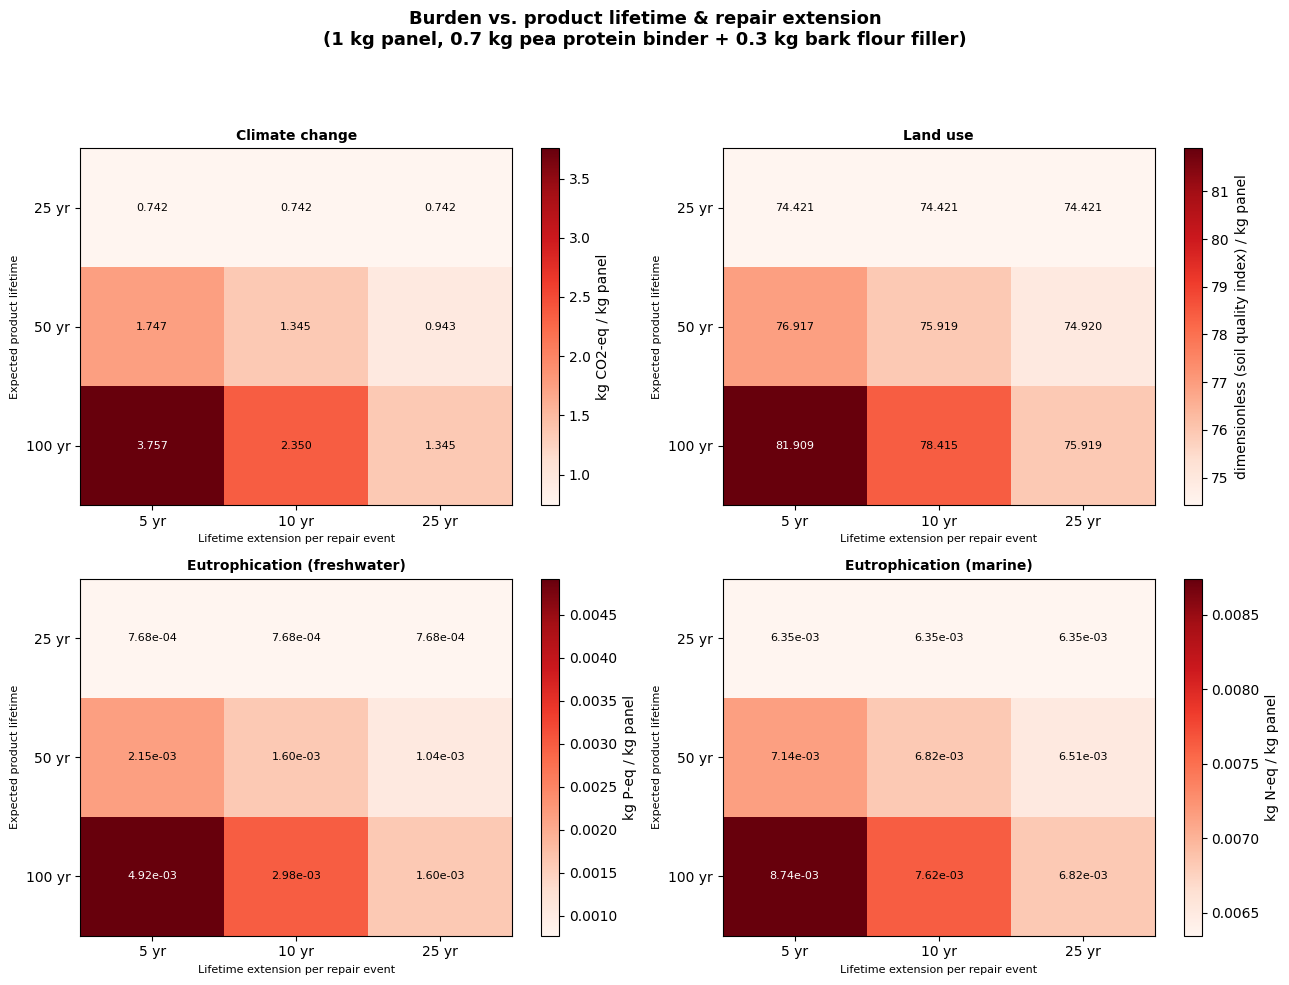

In [55]:
def auto_fmt(grid):
    """Picks a sensible number format based on the grid's magnitude — the
    categories here span kg CO2-eq (~1), soil quality index (~10-100), and
    kg P-eq / kg N-eq (~1e-3), so a single fixed format wouldn't read well
    across all four."""
    max_abs = np.max(np.abs(grid))
    if max_abs == 0:
        return "{:.3f}"
    if max_abs < 0.01 or max_abs >= 1000:
        return "{:.2e}"
    return "{:.3f}"


def plot_heatmap(ax, grid, title, cmap, cbar_label="kg CO2-eq / kg panel", center_zero=False, fmt=None):
    if fmt is None:
        fmt = auto_fmt(grid)
    if center_zero:
        vmax = np.max(np.abs(grid))
        vmin = -vmax
    else:
        vmin, vmax = grid.min(), grid.max()
    im = ax.imshow(grid, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(REPAIR_EXTENSION_YEARS)))
    ax.set_xticklabels([f"{e} yr" for e in REPAIR_EXTENSION_YEARS])
    ax.set_yticks(range(len(LIFETIME_YEARS)))
    ax.set_yticklabels([f"{l} yr" for l in LIFETIME_YEARS])
    ax.set_xlabel("Lifetime extension per repair event", fontsize=8)
    ax.set_ylabel("Expected product lifetime", fontsize=8)
    ax.set_title(title, fontsize=10, fontweight="bold")

    # Text color from actual cell luminance, same fix as the climate-change figure.
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap_obj = plt.get_cmap(cmap)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            val = grid[i, j]
            r, g, b, _ = cmap_obj(norm(val))
            luminance = 0.299 * r + 0.587 * g + 0.114 * b
            text_color = "white" if luminance < 0.5 else "black"
            ax.text(j, i, fmt.format(val), ha="center", va="center", fontsize=8, color=text_color)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.06, label=cbar_label)
    return im


fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, category in zip(axes.flat, IMPACT_CATEGORIES_ALL):
    unit = category_unit(df_mat_burdens, category)
    plot_heatmap(
        ax, burden_grids_all[category],
        SHORT_LABEL.get(category, category),
        cmap="Reds",
        cbar_label=f"{unit} / kg panel",
    )

fig.suptitle(
    "Burden vs. product lifetime & repair extension\n"
    "(1 kg panel, 0.7 kg pea protein binder + 0.3 kg bark flour filler)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("lifetime_repair_burden_heatmaps_all_categories.png", dpi=150, bbox_inches="tight")
plt.show()

## Activity & sub-activity contribution — climate change

Two rows, climate change only:
- **Row 1 (Production)**: the production-processes chart, then one breakdown
  chart per production-chain activity (mix preparation → ... → both EoL routes).
- **Row 2 (Ingredients)**: the ingredient-processes chart, then one breakdown
  chart for pea protein binder production and one for bark flour filler production.

Each breakdown chart's bars are that activity's own exchanges, valued at their
contribution to that activity's total.

**Predecessor exclusion.** Each breakdown chart drops the one bar that would
just repeat the *immediately preceding* activity in its chain (e.g. 3D
printing's breakdown no longer shows a "mix preparation" bar; Drying's no
longer shows "3D printing"). That value is already its own bar in the
top-level chart, and repeating it in every downstream breakdown just shows the
same large, growing number over and over while burying the genuinely new
information (each activity's own direct additions). I applied the same logic
to the ingredient side too — binder production's breakdown no longer shows
"AEIEP pea protein isolate production" — for consistency; flag me if you'd
rather keep AEIEP visible there.

Marginal (top-level chart) contributions are still computed from the *full*
exchange list regardless of this exclusion, so they remain correctly
double-counting-safe.

In [77]:
import bw2data as bd
import bw2calc as bc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Connect to project (skip if already connected earlier in this notebook) ──
bd.projects.set_current("biopol_lca")
DB_NAME = "lca_database_3DPrintedBiopol"
db = bd.Database(DB_NAME)


def find_activity(name):
    """Find a single foreground activity by exact name."""
    results = [a for a in db if a['name'] == name]
    if len(results) == 0:
        raise ValueError(f"Activity not found: '{name}'")
    if len(results) > 1:
        raise ValueError(f"Multiple activities found for: '{name}'")
    return results[0]


# ── Category for this figure ────────────────────────────────────────────────
CATEGORY = "climate change"
METHOD = [m for m in bd.methods if m[0] == 'EF v3.1' and m[1] == CATEGORY][0]
CATEGORY_UNIT = "kg CO2-eq"

In [78]:
# ── The one deliberate override in this analysis ──────────────────────────────
MIX_PREPARATION_NAME = "mix preparation"
RECIPE_OVERRIDE = {
    "pea protein binder production": 0.7,
    "bark flour filler production": 0.3,
    "cellulose filler production": 0.0,
    "cotton filler production": 0.0,
    "hemp dust filler production": 0.0,
    "seagrass filler production": 0.0,
    "wood flour filler production": 0.0,
}

PRODUCTION_CHAIN = [
    "mix preparation",
    "3D printing",
    "Drying with dehumidifying chamber",
    "Kiln baking",
    "on-site panel repair",
    "end of life: incineration",
    "end of life: closed-loop recycling",
]
INGREDIENT_CHAIN = [
    "AEIEP pea protein isolate production",
    "pea protein binder production",
    "bark flour filler production",
]
BREAKDOWN_ACTIVITIES = [
    "mix preparation",
    "3D printing",
    "Drying with dehumidifying chamber",
    "Kiln baking",
    "on-site panel repair",
    "end of life: incineration",
    "end of life: closed-loop recycling",
    "pea protein binder production",
    "bark flour filler production",
]

# Immediate predecessor of each activity within its own chain (list order) —
# used to drop the "previous process feeding into it" bar from breakdown
# charts, since that value is already its own bar in the top-level chart.
CHAIN_PREDECESSOR = {}
for _chain in (PRODUCTION_CHAIN, INGREDIENT_CHAIN):
    for i in range(1, len(_chain)):
        CHAIN_PREDECESSOR[_chain[i]] = _chain[i - 1]

_unit_impact_cache = {}


def get_exchange_amount(activity, exc):
    if activity['name'] == MIX_PREPARATION_NAME and exc.input['name'] in RECIPE_OVERRIDE:
        return RECIPE_OVERRIDE[exc.input['name']]
    return exc['amount']


def unit_impact(activity):
    """Cumulative (cradle-to-node) unit impact of 1 unit of `activity`'s own
    reference product."""
    key = activity.key
    if key in _unit_impact_cache:
        return _unit_impact_cache[key]

    if activity['database'] != DB_NAME:
        lca = bc.LCA({activity: 1}, METHOD)
        lca.lci()
        lca.lcia()
        score = lca.score
    else:
        score = 0.0
        for exc in activity.exchanges():
            if exc['type'] == 'production':
                continue
            amount = get_exchange_amount(activity, exc)
            score += amount * unit_impact(exc.input)

    _unit_impact_cache[key] = score
    return score


def exchange_breakdown(activity, exclude_chain_predecessor=True):
    """List of {label, amount, contribution, is_foreground} for one
    activity's own exchanges. With exclude_chain_predecessor=True (the
    default, used for display), the immediate chain-predecessor exchange is
    dropped."""
    predecessor_name = CHAIN_PREDECESSOR.get(activity['name'])
    rows = []
    for exc in activity.exchanges():
        if exc['type'] == 'production':
            continue
        if exclude_chain_predecessor and exc.input['name'] == predecessor_name:
            continue
        amount = get_exchange_amount(activity, exc)
        linked = exc.input
        contribution = amount * unit_impact(linked)
        rows.append({
            "label": linked['name'],
            "amount": amount,
            "contribution": contribution,
            "is_foreground": linked['database'] == DB_NAME,
        })
    return rows


def marginal_contribution(activity):
    """Own/direct contribution of `activity`. Always computed from the FULL
    exchange list (not the predecessor-excluded one), so it stays
    double-counting-safe regardless of what the breakdown chart displays."""
    total = unit_impact(activity)
    upstream = sum(
        r["contribution"] for r in exchange_breakdown(activity, exclude_chain_predecessor=False)
        if r["is_foreground"]
    )
    return total - upstream

In [79]:
PRODUCTION_COLORS = {
    "mix preparation": "#2b4a63",
    "3D printing": "#3a6690",
    "Drying with dehumidifying chamber": "#4f84b0",
    "Kiln baking": "#74a3c4",
    "on-site panel repair": "#9fc0d8",
    "end of life: incineration": "#c6dceb",
    "end of life: closed-loop recycling": "#e8f0f5",
}
INGREDIENT_COLORS = {
    "AEIEP pea protein isolate production": "#8a6a2f",
    "pea protein binder production": "#c9a24b",
    "bark flour filler production": "#6a994e",
}
BACKGROUND_COLOR = "#b0b0b0"

SHORT_NAME = {
    "mix preparation": "Mix prep",
    "3D printing": "3D printing",
    "Drying with dehumidifying chamber": "Drying",
    "Kiln baking": "Kiln baking",
    "on-site panel repair": "On-site repair",
    "end of life: incineration": "EoL: incineration",
    "end of life: closed-loop recycling": "EoL: recycling",
    "AEIEP pea protein isolate production": "AEIEP isolate",
    "pea protein binder production": "Binder production",
    "bark flour filler production": "Bark filler production",
}


def bar_color(name):
    return PRODUCTION_COLORS.get(name) or INGREDIENT_COLORS.get(name) or BACKGROUND_COLOR


charts = {}

charts["Production processes"] = [
    (SHORT_NAME[name], marginal_contribution(find_activity(name)), bar_color(name))
    for name in PRODUCTION_CHAIN
]
charts["Ingredient processes"] = [
    (SHORT_NAME[name], marginal_contribution(find_activity(name)), bar_color(name))
    for name in INGREDIENT_CHAIN
]
for name in BREAKDOWN_ACTIVITIES:
    rows = exchange_breakdown(find_activity(name))
    rows = [r for r in rows if abs(r["contribution"]) > 0]
    charts[SHORT_NAME[name]] = [
        (r["label"], r["contribution"], bar_color(r["label"])) for r in rows
    ]

# Sanity check
for name in BREAKDOWN_ACTIVITIES:
    activity = find_activity(name)
    predecessor_name = CHAIN_PREDECESSOR.get(name)
    full_rows = exchange_breakdown(activity, exclude_chain_predecessor=False)
    excluded_value = sum(r["contribution"] for r in full_rows if r["label"] == predecessor_name)
    expected = unit_impact(activity) - excluded_value
    bar_sum = sum(v for _, v, _ in charts[SHORT_NAME[name]])
    print(f"{name:45s} bars sum={bar_sum:.5f}  expected={expected:.5f}  match={abs(bar_sum-expected)<1e-9}")

mix preparation                               bars sum=0.47001  expected=0.47001  match=True
3D printing                                   bars sum=0.06435  expected=0.06435  match=True
Drying with dehumidifying chamber             bars sum=0.39994  expected=0.39994  match=True
Kiln baking                                   bars sum=0.18502  expected=0.18502  match=True
on-site panel repair                          bars sum=0.20101  expected=0.20101  match=True
end of life: incineration                     bars sum=-0.00770  expected=-0.00770  match=True
end of life: closed-loop recycling            bars sum=0.00753  expected=0.00753  match=True
pea protein binder production                 bars sum=0.11669  expected=0.11669  match=True
bark flour filler production                  bars sum=0.24917  expected=0.24917  match=True


/var/folders/jy/n4b2f9d16xbckrmnhmlqjc1w0000gq/T/ipykernel_38531/1787270226.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 1, 0.90])


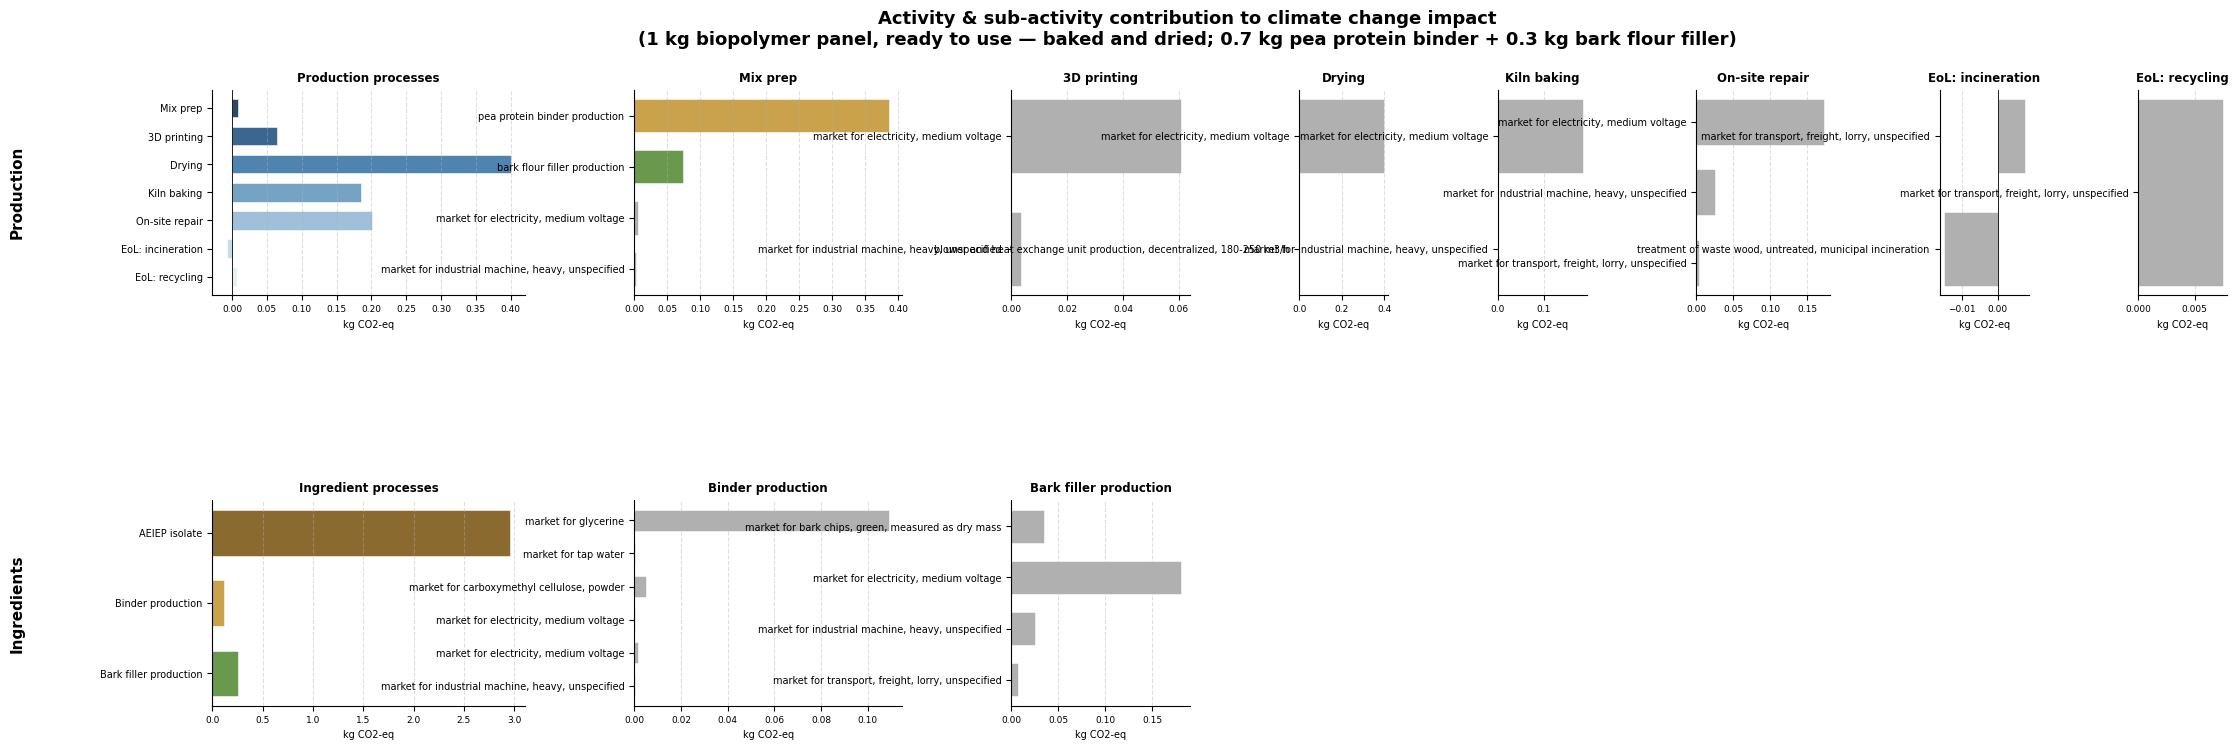

In [80]:
ROW1_CHARTS = [
    "Production processes", "Mix prep", "3D printing", "Drying",
    "Kiln baking", "On-site repair", "EoL: incineration", "EoL: recycling",
]
ROW2_CHARTS = ["Ingredient processes", "Binder production", "Bark filler production"]
N_COLS = max(len(ROW1_CHARTS), len(ROW2_CHARTS))


def plot_bar_chart(ax, bars, title):
    labels = [b[0] for b in bars]
    values = [b[1] for b in bars]
    colors = [b[2] for b in bars]
    y_pos = range(len(bars))

    ax.barh(y_pos, values, color=colors, edgecolor="white", linewidth=0.4, height=0.65)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=7)
    ax.invert_yaxis()
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_xlabel(CATEGORY_UNIT, fontsize=7)
    ax.tick_params(axis='x', labelsize=6.5)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(title, fontsize=8.5, fontweight="bold")


col_bar_counts = [
    max(len(charts.get(ROW1_CHARTS[c], [])), len(charts.get(ROW2_CHARTS[c], [])) if c < len(ROW2_CHARTS) else 0)
    for c in range(N_COLS)
]
width_ratios = [max(n, 2) for n in col_bar_counts]

fig = plt.figure(figsize=(26, 8))
gs = gridspec.GridSpec(2, N_COLS, width_ratios=width_ratios, hspace=1.0, wspace=0.7)

for col, chart_name in enumerate(ROW1_CHARTS):
    ax = fig.add_subplot(gs[0, col])
    plot_bar_chart(ax, charts[chart_name], chart_name)
    if col == 0:
        ax.annotate("Production", xy=(-0.6, 0.5), xycoords="axes fraction",
                     fontsize=11, fontweight="bold", ha="right", va="center", rotation=90)

for col, chart_name in enumerate(ROW2_CHARTS):
    ax = fig.add_subplot(gs[1, col])
    plot_bar_chart(ax, charts[chart_name], chart_name)
    if col == 0:
        ax.annotate("Ingredients", xy=(-0.6, 0.5), xycoords="axes fraction",
                     fontsize=11, fontweight="bold", ha="right", va="center", rotation=90)

fig.suptitle(
    "Activity & sub-activity contribution to climate change impact\n"
    "(1 kg biopolymer panel, ready to use — baked and dried; 0.7 kg pea protein binder + 0.3 kg bark flour filler)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout(rect=[0.02, 0, 1, 0.90])
plt.savefig("activity_contribution_climate_change.png", dpi=150, bbox_inches="tight")
plt.show()

## Drying calculations

In [22]:
"""
Drying energy model — climate-dependent version used in the factory siting tool.

This is a direct port of 01_LifeCycleInventory_master.ipynb, Section 10, with one
change: climate_temp_C and climate_rh are function arguments instead of hardcoded
constants (20°C, 0.80). Everything else — chamber design, material batch size,
COPs — is identical to the notebook and stays fixed regardless of climate.
"""

# ── Fixed batch/chamber parameters (climate-independent, from Section 10) ─────
CHAMBER_TEMP_C       = 20        # °C — chamber setpoint, does NOT vary with site
CHAMBER_RH           = 0.20      # relative humidity, chamber setpoint
ATM_PRESSURE_PA      = 101325    # Pa

CHAMBER_VOLUME_M3    = 5 * 6 * 3     # 90 m³
AIR_INFILTRATION_ACH = 1.0
DRYING_TIME_HRS      = 2 * 7 * 24    # 336 hrs (2 weeks)

N_PANELS             = 100
LITERS_PER_PANEL     = 0.5 * 0.5 * 0.05 * 1000   # 12.5 L
LITERS_MATERIAL      = N_PANELS * LITERS_PER_PANEL  # 1250 L
G_WATER_PER_LITER    = 682       # g/L, source: Carl
DENSITY_G_PER_LITER  = 850       # g/L, source: Carl
EVAPORATION_TARGET   = 0.75      # fraction of water removed

COP_DEHUMIDIFICATION = 2.0
COP_HEATING          = 3.0
COP_COOLING          = 3.0

AIR_DENSITY_KG_M3    = 1.2
SPECIFIC_HEAT_AIR    = 1.005     # kJ/kg·K


# ── Humidity calculations (Magnus approximation) — identical to notebook ──────
def sat_vapour_pressure(T_C):
    """Saturation vapour pressure (Pa) via the Magnus formula."""
    return 610.78 * 10 ** (7.5 * T_C / (237.3 + T_C))


def humidity_ratio(T_C, rh, P_atm):
    """Humidity ratio (kg water / kg dry air) from relative humidity."""
    p_sat = sat_vapour_pressure(T_C)
    p_v = rh * p_sat
    return 0.622 * p_v / (P_atm - p_v)


# ── Climate-independent derived quantities, computed once ─────────────────────
_abs_hum_chamber = humidity_ratio(CHAMBER_TEMP_C, CHAMBER_RH, ATM_PRESSURE_PA)
_m3_air_total = CHAMBER_VOLUME_M3 * AIR_INFILTRATION_ACH * DRYING_TIME_HRS
_kg_air_total = _m3_air_total * AIR_DENSITY_KG_M3
_kg_water_in_material = G_WATER_PER_LITER * LITERS_MATERIAL / 1000
_kg_water_from_material = _kg_water_in_material * EVAPORATION_TARGET
_kg_wet_material = LITERS_MATERIAL * DENSITY_G_PER_LITER / 1000
_kg_dry_material = _kg_wet_material - _kg_water_from_material
_enthalpy_vap_kJ_per_kg = 2501 - 2.37 * CHAMBER_TEMP_C  # uses chamber temp, not outdoor


def kwh_per_kg_dry(climate_temp_C, climate_rh):
    """
    Electricity demand for drying (kWh per kg of dry panel output),
    as a function of local outdoor climate (temperature in °C, RH as 0-1 fraction).

    Two contributions:
      1. Dehumidification — removing water from infiltrating outdoor air
         + from the wet material itself, divided by dehumidifier COP.
      2. Temperature control — heating or cooling infiltrating air to the
         chamber setpoint, divided by heat pump COP (heating or cooling).
    """
    abs_hum_outdoor = humidity_ratio(climate_temp_C, climate_rh, ATM_PRESSURE_PA)
    kg_water_from_air = (abs_hum_outdoor - _abs_hum_chamber) * _m3_air_total * AIR_DENSITY_KG_M3

    kwh_air = kg_water_from_air * _enthalpy_vap_kJ_per_kg / 3600 / COP_DEHUMIDIFICATION
    kwh_material = _kg_water_from_material * _enthalpy_vap_kJ_per_kg / 3600 / COP_DEHUMIDIFICATION
    kwh_dehum = kwh_air + kwh_material

    temp_diff = CHAMBER_TEMP_C - climate_temp_C
    kwh_temp_raw = _kg_air_total * SPECIFIC_HEAT_AIR * abs(temp_diff) / 3600
    if temp_diff == 0:
        kwh_temp = 0
    elif temp_diff < 0:
        kwh_temp = kwh_temp_raw / COP_COOLING   # outdoor warmer than chamber -> cooling
    else:
        kwh_temp = kwh_temp_raw / COP_HEATING   # outdoor cooler than chamber -> heating

    kwh_total_batch = kwh_dehum + kwh_temp
    return kwh_total_batch / _kg_dry_material


# ── Sanity check against your notebook's baseline (20°C, 80% RH) ──────────────
if __name__ == "__main__":
    baseline = kwh_per_kg_dry(20, 0.80)
    print(f"Baseline (20°C, 80% RH): {baseline:.5f} kWh/kg dry  (notebook value: 0.77255)")

    # A few example sites
    for label, T, RH in [
        ("Hot & humid (30°C, 85% RH)", 30, 0.85),
        ("Cold & dry (0°C, 60% RH)",    0, 0.60),
        ("Mild (15°C, 70% RH)",        15, 0.70),
        ("test", 23, 0.42)
    ]:
        val = kwh_per_kg_dry(T, RH)
        print(f"{label:30s} {val:.5f} kWh/kg  (ratio vs baseline: {val/baseline:.3f})")

Baseline (20°C, 80% RH): 0.77255 kWh/kg dry  (notebook value: 0.77255)
Hot & humid (30°C, 85% RH)     1.18133 kWh/kg  (ratio vs baseline: 1.529)
Cold & dry (0°C, 60% RH)       0.65626 kWh/kg  (ratio vs baseline: 0.849)
Mild (15°C, 70% RH)            0.68727 kWh/kg  (ratio vs baseline: 0.890)
test                           0.66877 kWh/kg  (ratio vs baseline: 0.866)
